# Differential Splicing
Based on the alternative splicing events, Isotools facilitates comparisons of samples and groups of samples. 


In this tutorial, we will apply the statistical test to find differential splicing between K562 and GM12878 (on chromosome 8), and how to interpret and depict the results. 

This tutorial assumes you have run the tutorial on [transcriptome reconstruction](03_transcriptome_reconstruction.html) already, and prepared the transcriptome pkl file "demo_isotools.pkl" based on the [demonstration data set](https://nc.molgen.mpg.de/cloud/index.php/s/Mf2zMePGBzFWFk8).

In [1]:
from isotools import Transcriptome
import logging
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.INFO)
logger = logging.getLogger('isotools')
# some GENCODE gene names/ids are shared across multiple genes; suppress the resulting
# lookup-ambiguity warnings for this demo (use the gene id instead of the name to avoid them)
logger.addFilter(lambda record: 'is ambiguous' not in record.getMessage())
import matplotlib.pyplot as plt
import pandas as pd

path='demonstration_dataset'
transcriptome=Transcriptome.load(f'{path}/demo_isotools.pkl')

INFO:loading transcriptome from demonstration_dataset/demo_isotools.pkl


## Statistical test for differential splicing
Differential splicing is implemented as a likelihood ratio test, based on beta-binomial model of the observed read counts. This model takes overdispersion due to variability within the groups into account, and is therefore appropriate to compare groups of samples.

<img src="isotools_diffsplice.png" alt= "Differential Splicing" style="background-color: white;">

The test is implemented in the method [altsplice_test](../isotoolsAPI.html?highlight=altsplice_test#isotools.Transcriptome.altsplice_test).
To run the test, we need to define the groups to compare, what types of splicing events are of interest, and the coverage threshold (over all samples) required to test an event. 
The resulting table contains the test statistics, including a description of the tested region, p-value, the transcript ids supporting outcome A or B of the event, group wise PSI and overdispersion values as well as sample wise coverage information.


In [2]:
#perform the test:
types_of_interest=['ES','ME','5AS','3AS','IR'] #ignore alternative TSS/PAS for now

diff_splice=transcriptome.altsplice_test(transcriptome.groups(),
                                  types=types_of_interest,
                                  min_total=200)
diff_splice=diff_splice.sort_values('pvalue').reset_index(drop=True)
sig=diff_splice.padj<.1

n_genes=len(diff_splice.loc[sig,"gene"].unique())
print(f'{sum(sig)} differential splice sites in {n_genes} genes for '+
      " vs ".join(transcriptome.groups()))
pd.set_option('display.max_columns', None)
diff_splice.head(18)
diff_splice.to_csv(f'{path}/demonstration_dataset_differential_events.csv',index = False)

INFO:testing differential splicing for GM12878 (3) vs K562 (3) using betabinom_lr test


18 differential splice sites in 16 genes for GM12878 vs K562


In [3]:
diff_splice

,gene,gene_id,chrom,strand,start,end,splice_type,novel,padj,pvalue,trA,trB,nmdA,nmdB,GM12878_PSI,GM12878_disp,K562_PSI,K562_disp,total_PSI,total_disp,GM12878_a_GM12878_in_cov,GM12878_a_GM12878_total_cov,GM12878_b_GM12878_in_cov,GM12878_b_GM12878_total_cov,GM12878_c_GM12878_in_cov,GM12878_c_GM12878_total_cov,K562_a_K562_in_cov,K562_a_K562_total_cov,K562_b_K562_in_cov,K562_b_K562_total_cov,K562_c_K562_in_cov,K562_c_K562_total_cov
0,RIPK2,ENSG00000104312.8,chr8,+,89780160,89786592,ES,True,0.000175,0.000001,"[16, 8, 26, 34, 41, 46, 32, 36, 39, 40, 42, 47...","[2, 0, 12, 9, 13, 4, 5, 10, 11, 14, 15, 17, 18...",0.549618,0.393939,0.994244,8.728419e-08,0.296339,1.059189e-05,0.719659,0.103622,76,76,218,220,224,225,34,104,41,153,34,111
1,ASAH1,ENSG00000104763.20,chr8,-,18067104,18067133,IR,True,0.007029,0.000135,"[11, 13, 80, 99, 69, 70, 101, 79, 81, 83, 88, ...","[12, 14, 68, 42, 44]",0.053030,0.012987,0.512441,1.078330e-03,0.010335,3.306517e-07,0.231512,0.069018,13,31,23,35,39,81,0,51,1,81,1,62
2,RECQL4,ENSG00000160957.15,chr8,-,144511789,144511910,5AS,False,0.007029,0.000145,"[22, 31, 6, 20, 11, 72, 13, 33, 8, 79, 2, 105,...","[114, 147, 124, 38, 143, 205, 123, 152, 197, 1...",0.465366,0.458904,0.012575,9.366640e-07,0.401486,1.211899e-04,0.240155,0.041071,1,150,1,9,0,1,278,666,127,301,177,482
3,SNHG6,ENSG00000245910.9,chr8,-,66922392,66922613,IR,False,0.011452,0.000409,"[1, 10, 17, 29, 16, 15, 6, 14, 19, 23, 24, 25,...","[3, 9]",1.000000,1.000000,0.255022,1.506108e-05,0.021488,1.779160e-06,0.128672,0.014606,5,26,13,45,21,82,1,70,3,72,1,91
4,SMIM19,ENSG00000176209.12,chr8,+,42541705,42546468,5AS,False,0.011452,0.000471,"[3, 4, 21]","[2, 5, 9, 26, 7, 17, 22, 24, 27, 28]",0.000000,0.019802,0.097171,1.705951e-02,0.593322,2.732809e-05,0.304097,0.074889,10,37,2,48,0,68,26,43,38,63,25,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,MRPS28,ENSG00000147586.10,chr8,-,80003180,80030053,5AS,True,1.000000,0.986636,"[5, 14, 30, 23]","[0, 4, 2, 20, 15, 22, 17, 32, 42, 13, 48, 18]",0.000000,0.003937,0.766587,1.523315e-05,0.776720,2.492912e-05,0.769574,0.000008,24,30,66,89,84,108,31,42,11,13,38,48
141,POLB,ENSG00000070501.12,chr8,+,42361365,42369270,ES,False,1.000000,0.994807,"[7, 11, 15, 20, 36, 40, 43]","[1, 0, 2, 12, 3, 10, 23, 24, 27, 35, 5, 9, 13,...",0.500000,0.442688,0.894198,1.207652e-05,0.894023,2.830737e-04,0.893994,0.000007,10,10,55,61,87,99,33,36,35,37,33,40
142,SCRIB,ENSG00000180900.20,chr8,-,143804825,143804954,5AS,False,1.000000,0.996899,"[31, 11, 94, 79, 56, 103, 142, 17, 155, 165, 4...","[5, 0, 14, 27, 36, 4, 18, 58, 6, 67, 12, 29, 3...",0.666667,0.670732,0.852941,NaN,0.854052,3.572960e-05,0.854019,0.000025,29,34,0,0,0,0,97,110,40,52,80,92
143,CHCHD7,ENSG00000170791.18,chr8,+,56214667,56216432,3AS,False,1.000000,1.000000,"[0, 7, 3, 6, 18, 33, 38, 2, 25, 9, 36, 50, 56,...","[1, 4, 5, 19, 26, 42, 48, 54, 32, 34, 37, 41, ...",0.058824,0.094937,0.229832,5.468918e-06,0.231743,4.678234e-06,0.230432,0.000002,22,95,22,110,56,230,19,93,15,53,24,104


## Depicting differential splicing results
To visualize deferentially spliced events, isotools implements a specific plot with the function [plot_diff_results](../isotoolsAPI.html?highlight=plot_diff_results#isotools.plots.plot_diff_results), summarizing the PSI values in the two groups. For each depicted event, two distributions represent the models posterior probability of PSI values for the two groups, as well as the observed PSI values for the individual samples as points. In addition, the isoform structure and read coverage over the event can be depicted as a sashimi-plot, using the Gene methods [sashimi_plot](../isotoolsAPI.html?highlight=sashimi_plot#isotools.Gene.sashimi_plot) and [gene_track](../isotoolsAPI.html?highlight=gene_track#isotools.Gene.gene_track).

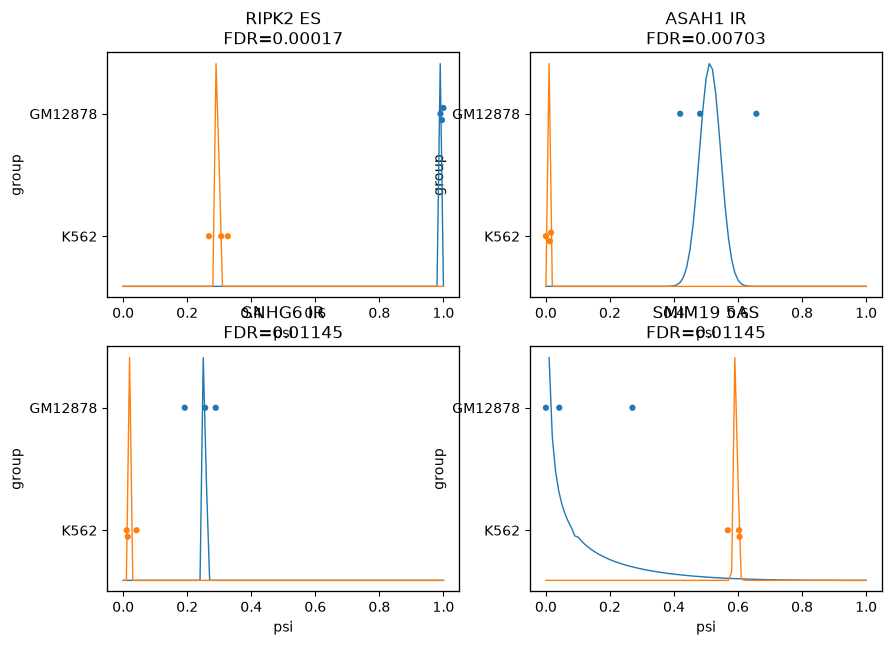

In [4]:
plt.rcParams["figure.figsize"] = (10,7)
from isotools.plots import plot_diff_results

f,axs,plotted=plot_diff_results(diff_splice,
                                min_diff=.1,
                                min_support=2,
                                grid_shape=(2,2),
                                group_colors=['C0','C1'])


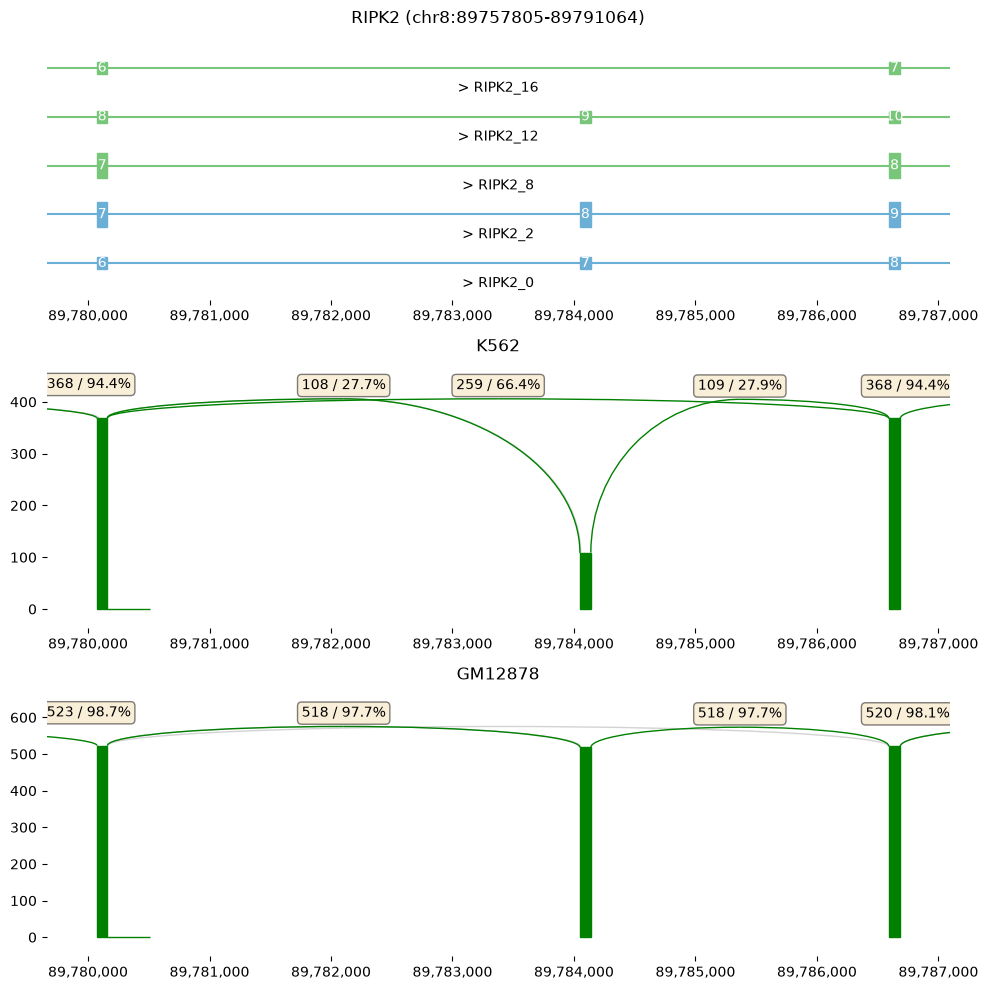

In [5]:
plt.rcParams["figure.figsize"] = (10,10)
pos=[89780160-500,89786592+500]
fig,axs=plt.subplots(3)
gene=transcriptome['RIPK2']
gene.gene_track(x_range=pos,
                ax=axs[0],
                reference=False,
                select_transcripts=gene.filter_transcripts('SUBSTANTIAL'))
gene.sashimi_plot(samples=transcriptome.groups()['K562'],
                  x_range=pos, ax=axs[1],
                  title='K562',
                  log_y=False)
gene.sashimi_plot(samples=transcriptome.groups()['GM12878'],
                  x_range=pos,
                  ax=axs[2],
                  title='GM12878',
                  log_y=False)

fig.tight_layout()

## Splicing coordination

A particular strength of long read sequencing is the fact that distal splicing events on the same gene are covered by the same read, facilitating analysis of splicing coordination. Isotools implements a pairwise independence test for all pairs of Alternative Splicing Events (ASEs) of a gene with the [coordination_test](../isotoolsAPI.html?highlight=coordination_test#isotools.Transcriptome.coordination_test) method. Each event has a primary (`pri`) and alternative (`alt`) state; for a pair of events A and B, every transcript falls into one of four combinations (`priA_priB`, `priA_altB`, `altA_priB`, `altA_altB`). These four counts form a 2x2 contingency table, which is tested for independence (Fisher's exact test by default).

In [6]:
coordination_results=transcriptome.coordination_test().sort_values('padj')
coordination_results.head()

,gene_id,gene_name,strand,eventA_type,eventB_type,eventA_start,eventA_end,eventB_start,eventB_end,pvalue,padj,statistic,log2OR,dcPSI_AB,dcPSI_BA,priA_priB,priA_altB,altA_priB,altA_altB,priA_priB_transcript_ids,priA_altB_transcript_ids,altA_priB_transcript_ids,altA_altB_transcript_ids
50,ENSG00000147813.16,NAPRT,-,IR,IR,143575093,143575190,143574900,143574985,8.463000e-78,1.040949e-75,92.901587,6.537631,0.523041,0.640535,472,45,14,124,"[0, 5, 6, 7, 54, 62, 73, 17, 100, 24, 30, 46, ...","[25, 48, 129, 68, 128, 33, 133, 101, 135, 141,...","[41, 96, 110, 112, 115]","[21, 1, 12, 31, 71, 44, 51, 63, 78, 92, 132, 1..."
104,ENSG00000182325.11,FBXL6,-,IR,IR,144357786,144358031,144357121,144357438,1.074270e-67,6.606760e-66,400.642857,8.646173,0.409171,0.434428,142,14,4,158,"[1, 21, 34, 7, 32, 36, 38, 72, 45, 81, 51, 85,...","[0, 29, 35, 71, 87, 89]","[4, 40]","[2, 9, 19, 31, 41, 14, 24, 44, 48, 56, 11, 54,..."
41,ENSG00000160957.15,RECQL4,-,IR,IR,144512771,144512846,144512324,144512391,7.923559e-53,3.248659e-51,15.489791,3.953246,0.381897,0.428869,1231,104,81,106,"[22, 31, 6, 20, 114, 147, 124, 11, 38, 72, 13,...","[2, 401, 191, 221, 94, 364, 68, 204, 250, 127,...","[117, 136, 279, 259, 271, 532, 292, 49, 184, 2...","[146, 21, 0, 107, 104, 408, 110, 112, 28, 29, ..."
54,ENSG00000167700.9,MFSD3,+,IR,IR,144510015,144510359,144510507,144510597,4.299909e-32,1.322222e-30,inf,38.459595,0.503866,0.743802,180,20,0,42,"[0, 3, 23, 35, 5, 38, 39]","[2, 21, 19, 20, 29]",[],"[11, 26, 14, 36, 18]"
105,ENSG00000182325.11,FBXL6,-,IR,IR,144357786,144358031,144356915,144356989,4.137357e-28,1.017790e-26,51.721154,5.692683,0.211262,0.420453,163,104,3,99,"[1, 12, 21, 34, 4, 7, 75, 86, 15, 23, 25, 26, ...","[2, 3, 41, 0, 24, 29, 44, 48, 49, 8, 17, 37, 6...","[32, 53]","[9, 19, 31, 14, 56, 11, 13, 54, 42, 59, 63, 64..."


The strongest result is a pair of intron retention (IR) events in *NAPRT*. Both are near the gene's 3' end (the low-coordinate end, since *NAPRT* is on the minus strand). The gene track below shows several transcripts with different combinations of these two introns retained or spliced out, and the sashimi plot shows the corresponding read support and junctions.

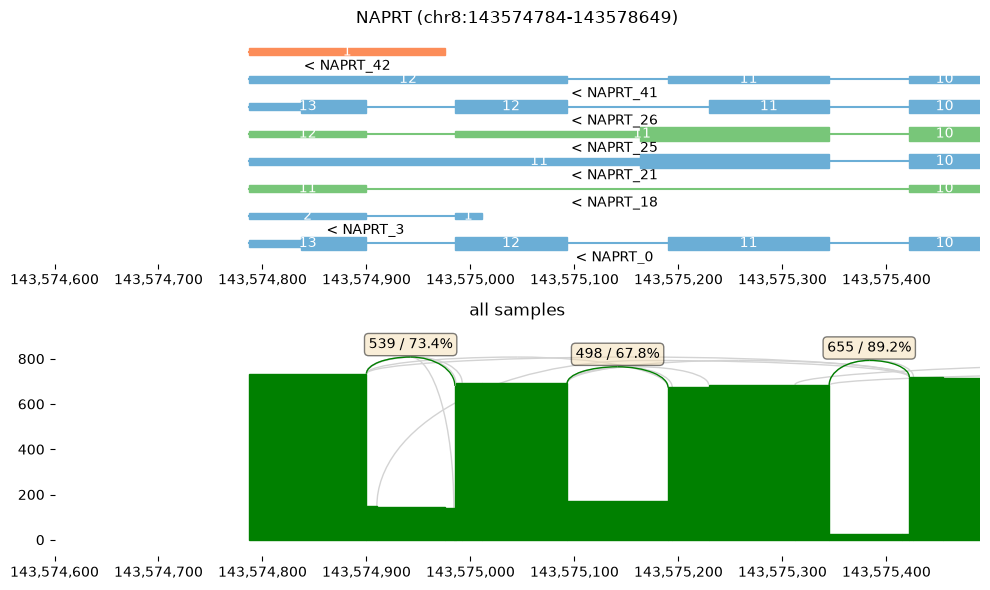

In [7]:
gene = transcriptome['NAPRT']
pos = [143574900 - 300, 143575190 + 300]
fig, axs = plt.subplots(2, figsize=(10, 6))
gene.gene_track(x_range=pos, ax=axs[0], reference=False, select_transcripts=gene.filter_transcripts('BALANCED'))
gene.sashimi_plot(x_range=pos, ax=axs[1], title='all samples', log_y=False)
fig.tight_layout()

The contingency table counts (`priA_priB`, `priA_altB`, `altA_priB`, `altA_altB`) give the number of transcripts observed in each combination of states, and `dcPSI_AB`/`dcPSI_BA` quantify the coordination directly as a change in PSI (percent spliced in):

* `dcPSI_AB` = PSI(B | A is alternative) - PSI(B) -- how much more (or less) often B is in its alternative state, given that A already is, compared to B's baseline
* `dcPSI_BA` = PSI(A | B is alternative) - PSI(A) -- the same, the other way round

Both are strongly positive for the *NAPRT* pair, meaning the two introns are retained together far more often than expected if they were spliced independently -- consistent with a single, partially-processed isoform, rather than two unrelated events.

In [8]:
top = coordination_results.iloc[0]
top[['eventA_start', 'eventA_end', 'eventB_start', 'eventB_end',
     'dcPSI_AB', 'dcPSI_BA', 'priA_priB', 'priA_altB', 'altA_priB', 'altA_altB']]

eventA_start    143575093
eventA_end      143575190
eventB_start    143574900
eventB_end      143574985
dcPSI_AB         0.523041
dcPSI_BA         0.640535
priA_priB             472
priA_altB              45
altA_priB              14
altA_altB             124
Name: 50, dtype: object

## Differential Isoform Expression
In addition to the differential splicing test, isotools also implements the differential isoform expression (DIE) test ([die_test](../isotoolsAPI.html?highlight=die_test#isotools.Transcriptome.die_test) method), as proposed by [Joglekar *et al.*, 2021](https://www.nature.com/articles/s41467-020-20343-5).
This test performs a $\chi^2$ test on the coverage table, to find genes where relative isoform expression is different between samples. 


In [9]:
transcriptome.die_test(groups=transcriptome.groups()).sort_values('pvalue').head(10)

INFO:testing differential isoform expression (DIE) for GM12878 (3) vs K562 (3).


,gene_id,gene_name,chrom,strand,start,end,padj,pvalue,deltaPI,transcript_ids
4726,ENSG00000161016.18,RPL8,chr8,-,144789764,144792587,0.000000e+00,0.000000e+00,-0.691603,"[80, 5]"
5001,ENSG00000156482.11,RPL30,chr8,-,98024850,98046469,0.000000e+00,0.000000e+00,0.516637,"[3, 2]"
5878,ENSG00000070756.17,PABPC1,chr8,-,100685815,100722809,0.000000e+00,0.000000e+00,-0.289215,"[2, 1]"
4100,ENSG00000147604.14,RPL7,chr8,-,73290241,73295789,1.456166e-170,1.885004e-172,0.092221,"[2, 31]"
4549,ENSG00000164924.18,YWHAZ,chr8,-,100916522,100953388,3.368695e-157,5.450963e-159,0.256012,"[0, 11]"
3180,ENSG00000104408.11,EIF3E,chr8,-,108162786,108443496,2.406840e-137,4.673475e-139,0.166874,"[0, 20]"
9888,ENSG00000104312.8,RIPK2,chr8,+,89757805,89791064,6.127843e-101,1.388185e-102,0.677697,"[2, 0]"
4160,ENSG00000129696.13,TTI2,chr8,-,33473385,33513185,9.427721e-100,2.440834e-101,-0.617118,"[3, 22]"
1502,ENSG00000104320.15,NBN,chr8,-,89924514,90003228,3.300988e-93,9.614527e-95,-0.409024,"[2, 1]"
3904,ENSG00000104529.19,EEF1D,chr8,-,143579696,143599541,1.438238e-74,4.654490e-76,0.339486,"[5, 12]"


## Conclusion

This tutorial covered:

* testing for differential splicing between groups with `altsplice_test`, and visualizing results with `plot_diff_results` and sashimi plots
* testing whether pairs of splicing events within a gene are coordinated with `coordination_test`
* testing for differential isoform expression with `die_test`